Кейс №2 - Приложение доставки

Вы работаете аналитиком в приложении по доставке продуктов. Команда внедрила в приложение умную систему рекомендации товаров – предполагается, что такая система поможет пользователям эффективнее работать с приложением и лучше находить необходимые товары.

Чтобы проверить эффективность системы рекомендаций, был проведен АБ-тест. В группе 1 оказались пользователи с новой системой рекомендаций, в группе 0 пользователи со старой версией приложения, где нет рекомендации товаров.

Ваша задача – оценить, смогла ли новая система рекомендаций принести пользу бизнесу и пользователям приложения. Для этого нужно выбрать метрики, которые отвечают за качество сервиса, и статистически сравнить эти метрики в двух группах.

Результат вашей работы – аналитическое заключение с ответом на вопрос, стоит ли включать новую систему рекомендаций на всех пользователей.

В данных вы найдете логи заказов пользователей:

ab_users_data – история заказов пользователей, в этой таблице есть информация о том, какие заказы создавали и отменяли пользователи
ab_orders – подробная информация о составе заказа, тут для каждого заказа есть список id тех продуктов, которые были включены в заказ
ab_products – подробная информация о продуктах, их название и стоимость

In [69]:
import pandas as pd
from scipy import stats
from scipy.stats import chi2_contingency, chi2
import scipy.stats as ss
import numpy as np
import matplotlib.pyplot as plt
import pingouin as pg
import seaborn as sns
from statsmodels.stats.multicomp import (pairwise_tukeyhsd,
                                         MultiComparison) 
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

In [3]:
ab_users_data = pd.read_csv('C://Users//Admin//Desktop//Devs//anal//ab_users_data.csv')
ab_orders = pd.read_csv('C://Users//Admin//Desktop//Devs//anal//ab_orders.csv')
ab_products = pd.read_csv('C://Users//Admin//Desktop//Devs//anal//ab_products.csv')

In [4]:
ab_users_data.head()

,user_id,order_id,action,time,date,group
0,964,1255,create_order,2022-08-26 00:00:19.000000,2022-08-26,0
1,965,1256,create_order,2022-08-26 00:02:21.000000,2022-08-26,1
2,964,1257,create_order,2022-08-26 00:02:27.000000,2022-08-26,0
3,966,1258,create_order,2022-08-26 00:02:56.000000,2022-08-26,0
4,967,1259,create_order,2022-08-26 00:03:37.000000,2022-08-26,1


In [5]:
ab_users_data.dtypes #проверка типоа данных

user_id      int64
order_id     int64
action      object
time        object
date        object
group        int64
dtype: object

In [6]:
ab_users_data.isna().sum() #проверка пропущеных значений

user_id     0
order_id    0
action      0
time        0
date        0
group       0
dtype: int64

In [7]:
ab_orders.head()

,order_id,creation_time,product_ids
0,1255,2022-08-26 00:00:19.000000,"{75, 22, 53, 84}"
1,1256,2022-08-26 00:02:21.000000,"{56, 76, 39}"
2,1257,2022-08-26 00:02:27.000000,"{76, 34, 41, 38}"
3,1258,2022-08-26 00:02:56.000000,"{74, 6}"
4,1259,2022-08-26 00:03:37.000000,"{20, 45, 67, 26}"


In [8]:
ab_orders.dtypes #проверка типоа данных

order_id          int64
creation_time    object
product_ids      object
dtype: object

In [9]:
ab_orders.isna().sum() #проверка пропущеных значений

order_id         0
creation_time    0
product_ids      0
dtype: int64

In [10]:
ab_products.head()

,product_id,name,price
0,1,сахар,150.0
1,2,чай зеленый в пакетиках,50.0
2,3,вода негазированная,80.4
3,4,леденцы,45.5
4,5,кофе 3 в 1,15.0


In [11]:
ab_products.dtypes #проверка типоа данных

product_id      int64
name           object
price         float64
dtype: object

In [12]:
ab_products.isna().sum() #проверка пропущеных значений

product_id    0
name          0
price         0
dtype: int64

In [13]:
#пользователи первой группы
group0_list = list(set(ab_users_data.query("group==0").user_id.tolist()))
len(group0_list)

515

In [14]:
#пользователи второй группы
group1_list = list(set(ab_users_data.query("group==1").user_id.tolist()))
len(group1_list)

502

In [15]:
#проверим, есть ли пользователи, которые попали одновременны в обе группы
#таких пользователей нет
np.intersect1d(group0_list, group1_list)

array([], dtype=int32)

In [27]:
ab_orders.product_ids = ab_orders.product_ids.apply(lambda x: x.replace('{', '').replace('}', '').split(','))

In [28]:
ab_orders

,order_id,creation_time,product_ids
0,1255,2022-08-26 00:00:19.000000,"[75, 22, 53, 84]"
1,1256,2022-08-26 00:02:21.000000,"[56, 76, 39]"
2,1257,2022-08-26 00:02:27.000000,"[76, 34, 41, 38]"
3,1258,2022-08-26 00:02:56.000000,"[74, 6]"
4,1259,2022-08-26 00:03:37.000000,"[20, 45, 67, 26]"
...,...,...,...
4118,59422,2022-09-08 23:13:03.000000,"[84, 8, 24]"
4119,59439,2022-09-08 23:18:05.000000,"[9, 25, 75, 30, 6]"
4120,59464,2022-09-08 23:22:27.000000,"[60, 41, 46]"
4121,59487,2022-09-08 23:29:06.000000,"[9, 62, 77]"


<Axes: xlabel='group', ylabel='Count'>

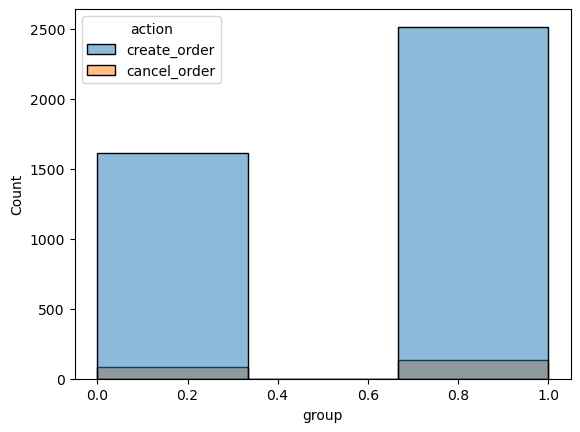

In [30]:
sns.histplot(data=ab_users_data, x='group', hue='action', bins=3) #проверим, повлияла ли реклама на отмену заказов

Проверим методом Хи-квадрат. 
H0 - частота отмены заказов не зависит от группы

H1 - частота отмены заказов зависит от группы

In [33]:
chi2_contingency(pd.crosstab(ab_users_data.action, ab_users_data.group))

Chi2ContingencyResult(statistic=0.018211165651942023, pvalue=0.8926523935841298, dof=1, expected_freq=array([[  83.43878257,  130.56121743],
       [1607.56121743, 2515.43878257]]))

p-value > 0.5 - нет оснований отклонить нулевую гипотезу - я делаю вывод что введение новой системы рекомендаций не влияет на количество отмен

In [39]:
cancel_list = ab_users_data.query("action == 'cancel_order'").order_id.to_list()
users_data = ab_users_data.query("order_id not in @cancel_list")

In [41]:
users_data = users_data.merge(ab_orders, on='order_id', how='left') 
#объединим таблицы

In [42]:
users_data

,user_id,order_id,action,time,date,group,creation_time,product_ids
0,964,1255,create_order,2022-08-26 00:00:19.000000,2022-08-26,0,2022-08-26 00:00:19.000000,"[75, 22, 53, 84]"
1,965,1256,create_order,2022-08-26 00:02:21.000000,2022-08-26,1,2022-08-26 00:02:21.000000,"[56, 76, 39]"
2,964,1257,create_order,2022-08-26 00:02:27.000000,2022-08-26,0,2022-08-26 00:02:27.000000,"[76, 34, 41, 38]"
3,967,1259,create_order,2022-08-26 00:03:37.000000,2022-08-26,1,2022-08-26 00:03:37.000000,"[20, 45, 67, 26]"
4,968,1261,create_order,2022-08-26 00:05:35.000000,2022-08-26,0,2022-08-26 00:05:35.000000,"[30, 35, 69, 6]"
...,...,...,...,...,...,...,...,...
3904,990,59422,create_order,2022-09-08 23:13:03.000000,2022-09-08,1,2022-09-08 23:13:03.000000,"[84, 8, 24]"
3905,1418,59439,create_order,2022-09-08 23:18:05.000000,2022-09-08,1,2022-09-08 23:18:05.000000,"[9, 25, 75, 30, 6]"
3906,1605,59464,create_order,2022-09-08 23:22:27.000000,2022-09-08,0,2022-09-08 23:22:27.000000,"[60, 41, 46]"
3907,1461,59487,create_order,2022-09-08 23:29:06.000000,2022-09-08,0,2022-09-08 23:29:06.000000,"[9, 62, 77]"


In [55]:
users_data['qantity'] = users_data.product_ids.apply(lambda x: len(x))

In [58]:
users_data

,user_id,order_id,action,time,date,group,creation_time,product_ids,qantity
0,964,1255,create_order,2022-08-26 00:00:19.000000,2022-08-26,0,2022-08-26 00:00:19.000000,"[75, 22, 53, 84]",4
1,965,1256,create_order,2022-08-26 00:02:21.000000,2022-08-26,1,2022-08-26 00:02:21.000000,"[56, 76, 39]",3
2,964,1257,create_order,2022-08-26 00:02:27.000000,2022-08-26,0,2022-08-26 00:02:27.000000,"[76, 34, 41, 38]",4
3,967,1259,create_order,2022-08-26 00:03:37.000000,2022-08-26,1,2022-08-26 00:03:37.000000,"[20, 45, 67, 26]",4
4,968,1261,create_order,2022-08-26 00:05:35.000000,2022-08-26,0,2022-08-26 00:05:35.000000,"[30, 35, 69, 6]",4
...,...,...,...,...,...,...,...,...,...
3904,990,59422,create_order,2022-09-08 23:13:03.000000,2022-09-08,1,2022-09-08 23:13:03.000000,"[84, 8, 24]",3
3905,1418,59439,create_order,2022-09-08 23:18:05.000000,2022-09-08,1,2022-09-08 23:18:05.000000,"[9, 25, 75, 30, 6]",5
3906,1605,59464,create_order,2022-09-08 23:22:27.000000,2022-09-08,0,2022-09-08 23:22:27.000000,"[60, 41, 46]",3
3907,1461,59487,create_order,2022-09-08 23:29:06.000000,2022-09-08,0,2022-09-08 23:29:06.000000,"[9, 62, 77]",3


Оценим, влияет ли система рекомендаций количество товаров в одном чеке

In [61]:
gr0 = users_data.query("group == 0").qantity
gr1 = users_data.query("group == 1").qantity


C:\Users\Admin\AppData\Local\Temp\ipykernel_10704\1569129963.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gr0, bins=8)
C:\Users\Admin\AppData\Local\Temp\ipykernel_10704\1569129963.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gr1, bins=8)


<Axes: xlabel='qantity', ylabel='Density'>

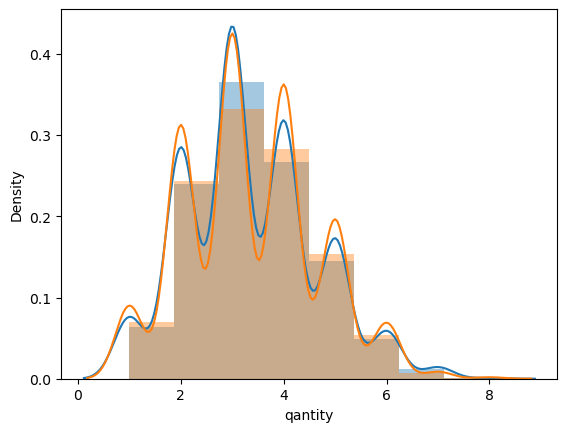

In [62]:
sns.distplot(gr0, bins=8)
sns.distplot(gr1, bins=8)

По графику сложно оценить различия, кажется что их нет.

Найдем среднее значение количества товаров в одном чеке для каждой группы.

In [63]:
gr0.mean()

3.341846758349705

In [64]:
gr1.mean()

3.350125944584383

Средние почти одинаковые, сделаем т - тест

In [70]:
ss.ttest_ind(gr0, gr1)

Ttest_indResult(statistic=-0.19638057741712578, pvalue=0.84432251088501)

pvalue больше 0,05 - статистических различий нет

Посмотрим, увеличит ли использование новой рекомендательной системы среднее значение суммы в чеке. Для этого создадим таблицу

In [81]:
users_data = users_data.explode('product_ids').rename(columns = {'product_ids': 'product_id'})

KeyError: 'product_ids'

In [84]:
users_data.product_id = users_data.product_id.astype('int64')

In [85]:
users_data.dtypes

user_id           int64
order_id          int64
action           object
time             object
date             object
group             int64
creation_time    object
product_id        int64
qantity           int64
dtype: object

In [86]:
users_data = users_data.merge(ab_products, on='product_id', how='left') 

In [87]:
users_data

,user_id,order_id,action,time,date,group,creation_time,product_id,qantity,name,price
0,964,1255,create_order,2022-08-26 00:00:19.000000,2022-08-26,0,2022-08-26 00:00:19.000000,75,4,сок ананасовый,120.0
1,964,1255,create_order,2022-08-26 00:00:19.000000,2022-08-26,0,2022-08-26 00:00:19.000000,22,4,сок мультифрукт,120.0
2,964,1255,create_order,2022-08-26 00:00:19.000000,2022-08-26,0,2022-08-26 00:00:19.000000,53,4,мука,78.3
3,964,1255,create_order,2022-08-26 00:00:19.000000,2022-08-26,0,2022-08-26 00:00:19.000000,84,4,мандарины,90.4
4,965,1256,create_order,2022-08-26 00:02:21.000000,2022-08-26,1,2022-08-26 00:02:21.000000,56,3,сосиски,150.0
...,...,...,...,...,...,...,...,...,...,...,...
13078,1461,59487,create_order,2022-09-08 23:29:06.000000,2022-09-08,0,2022-09-08 23:29:06.000000,9,3,чай черный листовой,83.5
13079,1461,59487,create_order,2022-09-08 23:29:06.000000,2022-09-08,0,2022-09-08 23:29:06.000000,62,3,сок яблочный,120.0
13080,1461,59487,create_order,2022-09-08 23:29:06.000000,2022-09-08,0,2022-09-08 23:29:06.000000,77,3,курица,298.4
13081,1376,59533,create_order,2022-09-08 23:41:24.000000,2022-09-08,0,2022-09-08 23:41:24.000000,17,2,морс брусничный,190.0


Сравним суммы чеков в группах

In [90]:
gr0 = users_data.query("group == 0").groupby('order_id', as_index=False).agg({'price': 'sum'}).price
gr1 = users_data.query("group == 1").groupby('order_id', as_index=False).agg({'price': 'sum'}).price

C:\Users\Admin\AppData\Local\Temp\ipykernel_10704\1569129963.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gr0, bins=8)
C:\Users\Admin\AppData\Local\Temp\ipykernel_10704\1569129963.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gr1, bins=8)


<Axes: xlabel='price', ylabel='Density'>

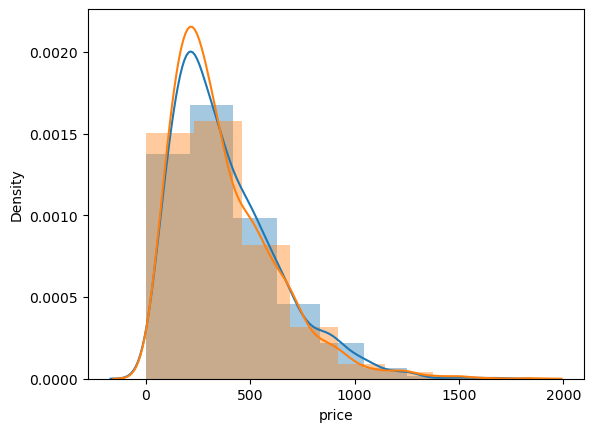

In [91]:
sns.distplot(gr0, bins=8)
sns.distplot(gr1, bins=8)

In [92]:
gr0.mean()

382.09292730844794

In [94]:
gr1.mean()

368.86162888329136

По графику и средним кажется, что нет особых роазличий

In [95]:
ss.ttest_ind(gr0, gr1)

Ttest_indResult(statistic=1.6334875192269402, pvalue=0.10244707728234669)

pvalue больше 0,05 - статистических различий нет

Сравним средний чек пользоватетей

In [107]:
gr0 = users_data\
    .query("group == 0")\
    .groupby(['user_id', 'order_id'], as_index=False)\
    .agg({'price': 'sum'})\
    .groupby('user_id', as_index=False)\
    .agg({'price': 'mean'})\
    .price
gr1 = users_data\
    .query("group == 1")\
    .groupby(['user_id', 'order_id'], as_index=False)\
    .agg({'price': 'sum'})\
    .groupby('user_id', as_index=False)\
    .agg({'price': 'mean'})\
    .price


C:\Users\Admin\AppData\Local\Temp\ipykernel_10704\1569129963.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gr0, bins=8)
C:\Users\Admin\AppData\Local\Temp\ipykernel_10704\1569129963.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gr1, bins=8)


<Axes: xlabel='price', ylabel='Density'>

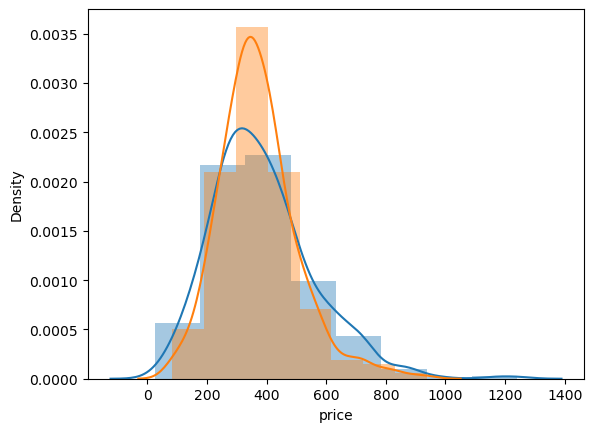

In [108]:
sns.distplot(gr0, bins=8)
sns.distplot(gr1, bins=8)

In [105]:
gr0.mean()

386.03905270185544

In [109]:
gr1.mean()

371.2036217464062

In [110]:
ss.ttest_ind(gr0, gr1)

Ttest_indResult(statistic=1.5407052777251002, pvalue=0.12370144988523067)

pvalue больше 0,05 - статистических различий нет

Сравним количесво продуктов, покупаемых пользователями

In [111]:
gr0 = users_data.query("group == 0").groupby('user_id', as_index=False).agg({'qantity': 'mean'}).qantity
gr1 = users_data.query("group == 1").groupby('user_id', as_index=False).agg({'qantity': 'mean'}).qantity

C:\Users\Admin\AppData\Local\Temp\ipykernel_10704\1569129963.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gr0, bins=8)
C:\Users\Admin\AppData\Local\Temp\ipykernel_10704\1569129963.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gr1, bins=8)


<Axes: xlabel='qantity', ylabel='Density'>

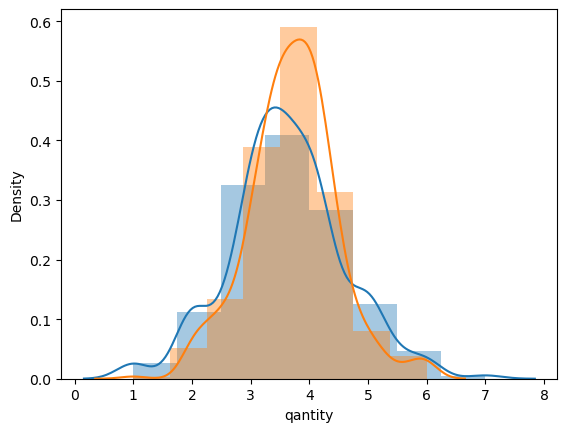

In [112]:
sns.distplot(gr0, bins=8)
sns.distplot(gr1, bins=8)

In [113]:
gr0.mean()

3.611880057800392

In [114]:
gr1.mean()

3.718035921516803

In [115]:
ss.ttest_ind(gr0, gr1)

Ttest_indResult(statistic=-1.9368359904554189, pvalue=0.05304374317736419)

pvalue больше 0,05 - статистических различий нет

In [ ]:
проверим влияние на количество заказов пользователей

In [116]:
gr0 = users_data.query("group == 0").groupby('user_id', as_index=False).agg({'order_id': 'count'}).order_id
gr1 = users_data.query("group == 1").groupby('user_id', as_index=False).agg({'order_id': 'count'}).order_id

C:\Users\Admin\AppData\Local\Temp\ipykernel_10704\1569129963.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gr0, bins=8)
C:\Users\Admin\AppData\Local\Temp\ipykernel_10704\1569129963.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gr1, bins=8)


<Axes: xlabel='order_id', ylabel='Density'>

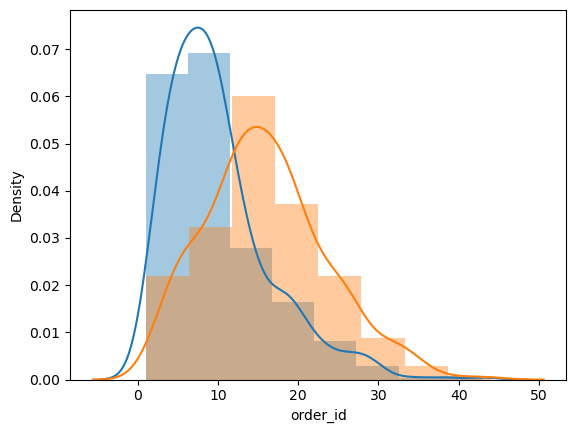

In [117]:
sns.distplot(gr0, bins=8)
sns.distplot(gr1, bins=8)

In [118]:
gr0.mean()

9.966796875

In [120]:
gr1.mean()

15.928143712574851

In [121]:
ss.ttest_ind(gr0, gr1)

Ttest_indResult(statistic=-13.447531897806387, pvalue=4.795189289548436e-38)

pvalue < 0.05 - есть статистически значимые различия

Вывод: рекомендательная система повлияла на увеличение количества заказов. Не повлияла, на средний чек, и количество товаров в чеке.